In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from google.cloud import bigquery
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer

In [ ]:
key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)

    query = """
        SELECT * FROM `csci-4022.CSCI.fraud_data`
    """

    print("Fetching the FULL dataset. This may take a moment...")
    df = client.query(query).to_dataframe()

    print(f"Success! Loaded {len(df):,} rows.")
    print(df.info())
else:
    print("Key file not found.")

In [3]:
sentinel_cols = [
    'prev_address_months_count',
    'intended_balcon_amount',
    'bank_months_count',
    'device_distinct_emails_8w'
] # Columns where -1 is missing data instead of NaN

df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)

#Categorizing column types
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

#Eliminating fraud target from numeric list
if "fraud_bool" in numeric_cols:
    numeric_cols.remove("fraud_bool")

In [4]:
# Split data into features and target, then into training and test sets
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
print(df.shape)

(999999, 32)


In [13]:
# Repeat column type categorization for train/test splits
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #Fills missing values with median for numeric columns
    ("scaler", StandardScaler()) #Normalizes numeric features to have mean=0 and std=1
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #Fills missing values with the most frequent category for categorical columns
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=True)) #One hot encodes categorical features 
])

# Combine pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols), #Applies numeric pipeline to numeric columns
        ("cat", categorical_transformer, categorical_cols) #Applies categorical pipeline to categorical columns
    ]
)

X_train_processed = preprocessor.fit_transform(X_train) 
X_test_processed = preprocessor.transform(X_test)
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (799999, 51)
Processed test shape: (200000, 51)


In [14]:
np.random.seed(42)

sample_size = int(0.2 * X_train_processed.shape[0]) # takes arandom 20% of training data
sample_idx = np.random.choice(X_train_processed.shape[0], size=sample_size, replace=False) # Randomly chooses indicies for the sample without replacment 

X_train_sample = X_train_processed[sample_idx] # Grabs the rwos from the features 
y_train_sample = y_train.iloc[sample_idx] # Grabs teh matching labels for the sample

print(f"Training on {X_train_sample.shape[0]} samples")

# Fast linear SVM for large sparse data
# Uses a diffrent optimizer that sacales better with this large amount of data
svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42,max_iter=5000)
svm.fit(X_train_processed, y_train) # Fits the linear SVM model to the sampled training data

# Evaluate on sparse test matrix
threshold = 0.2 # Chose this threshold based on the training set performance to balance recall and precision
svm_pred = svm.predict(X_test_processed)


print("LINEAR SVM EVALUATION")
print(f"Recall   : {recall_score(y_test, svm_pred):.4f}")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, svm_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Training on 159999 samples
LINEAR SVM EVALUATION
Recall   : 0.7842
Precision: 0.0432
F1-Score : 0.0820

Confusion Matrix:
[[159522  38272]
 [   476   1730]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.81      0.89    197794
         1.0       0.04      0.78      0.08      2206

    accuracy                           0.81    200000
   macro avg       0.52      0.80      0.49    200000
weighted avg       0.99      0.81      0.88    200000



In [15]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) #Builds a simple KNN classifier
knn.fit(X_train_sample, y_train_sample)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [16]:
knn_pred = knn.predict(X_test_processed)

print("KNN EVALUATION")
print(f"Recall   : {recall_score(y_test, knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, knn_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

KNN EVALUATION
Recall   : 0.0086
Precision: 0.1900
F1-Score : 0.0165

Confusion Matrix:
[[197713     81]
 [  2187     19]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    197794
         1.0       0.19      0.01      0.02      2206

    accuracy                           0.99    200000
   macro avg       0.59      0.50      0.51    200000
weighted avg       0.98      0.99      0.98    200000



In [17]:

calibrated_svc = CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000), cv=3) # Logistic regression as meta-learner
stacking_clf = StackingClassifier(estimators=[('svc', calibrated_svc), ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))], final_estimator=LogisticRegression(class_weight="balanced"), cv=5, passthrough=False) # Stacking applied to SVM and KNN
stacking_clf.fit(X_train_sample, y_train_sample) # Fits the stacking method 
stacking_pred = stacking_clf.predict(X_test_processed) #Evaluates the stacking method on the test set

In [18]:
print("STACKING ENSEMBLE EVALUATION")                                                                                                                                                                                                                                                                                                                                                                   
print(f"Recall   : {recall_score(y_test, stacking_pred):.4f}")                                                                                                                                                 
print(f"Precision: {precision_score(y_test, stacking_pred):.4f}")                                                                                                                                              
print(f"F1-Score : {f1_score(y_test, stacking_pred):.4f}")                                                                                                                                                     
print("\nConfusion Matrix:")                                                                                                                                                                                   
print(confusion_matrix(y_test, stacking_pred))                                                                                                                                                                 
print("\nClassification Report:")                                                                                                                                                                              
print(classification_report(y_test, stacking_pred))

STACKING ENSEMBLE EVALUATION
Recall   : 0.6183
Precision: 0.0718
F1-Score : 0.1287

Confusion Matrix:
[[180164  17630]
 [   842   1364]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95    197794
         1.0       0.07      0.62      0.13      2206

    accuracy                           0.91    200000
   macro avg       0.53      0.76      0.54    200000
weighted avg       0.99      0.91      0.94    200000



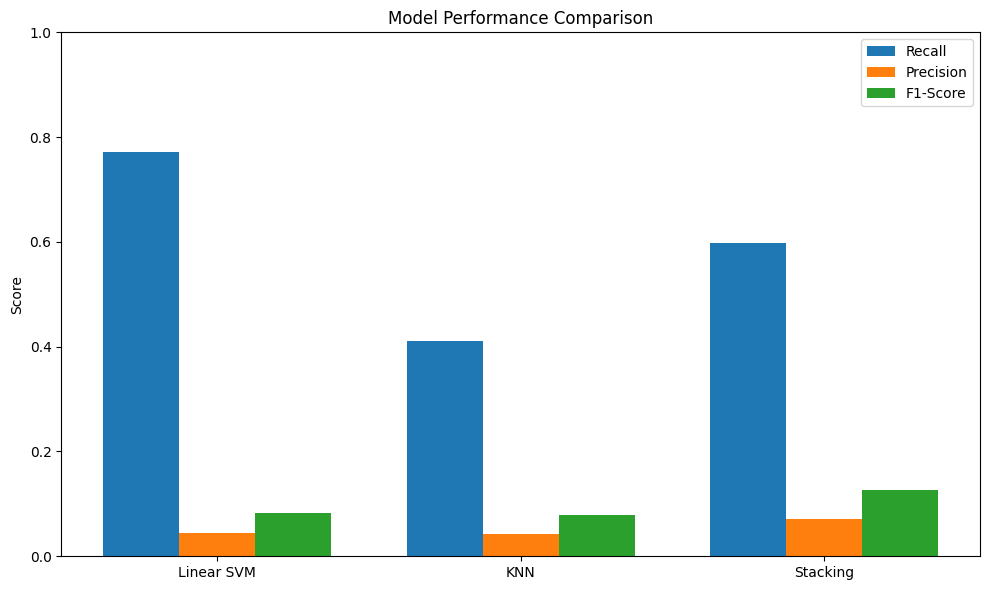

In [19]:
import matplotlib.pyplot as plt                                                                                                                                                                          
import numpy as np                                                                                                                                                                                       
                                                                                                                                                                                                        
models = ['Linear SVM', 'KNN', 'Stacking']                                                                                                                                                               
recall= [0.7711, 0.4116, 0.5979]                                                                                                                                                                     
precision =[0.0438, 0.0431, 0.0705]                                                                                                                                                                  
f1 =[0.0829, 0.0780, 0.1262]        
                                        
x = np.arange(len(models))                                                                                                                                                                               
width = 0.25                                                                                                                                                                                             
                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(10, 6))                                                                                                                                                                  
ax.bar(x - width, recall, width, label='Recall')                                                                                                                                                         
ax.bar(x, precision, width, label='Precision')                                                                                                                                                           
ax.bar(x + width, f1, width, label='F1-Score')                                                                                                                                                           
                                                                                                                                                                                                        
ax.set_ylabel('Score')                                                                                                                                                                                   
ax.set_title('Model Performance Comparison')                                                                                                                                                             
ax.set_xticks(x)                                                                                                                                                                                         
ax.set_xticklabels(models)                                                                                                                                                                               
ax.legend()                                                                                                                                                                                              
ax.set_ylim(0, 1)                                                                                                                                                                                        
plt.tight_layout()                                                                                                                                                                                    
plt.show()    

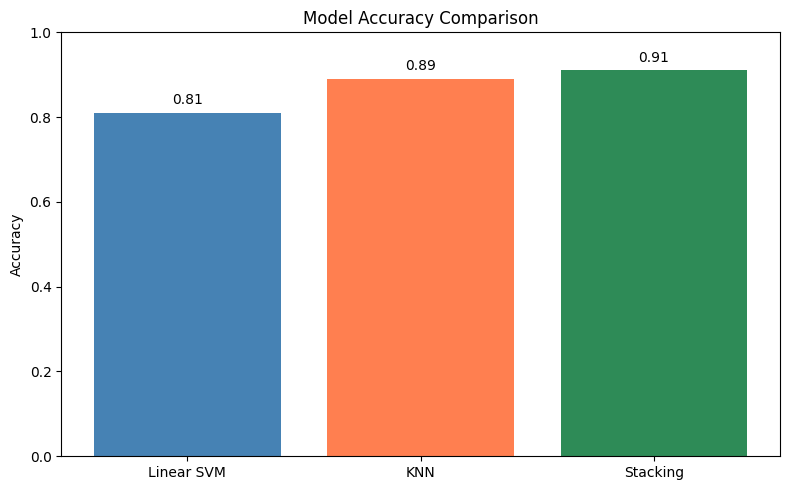

In [20]:
models = ['Linear SVM', 'KNN', 'Stacking']                                                                                                                                                               
accuracy = [0.81, 0.89, 0.91]                                                                                                                                                                            
                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(8, 5))                                                                                                                                                                   
bars = ax.bar(models, accuracy, color=['steelblue', 'coral', 'seagreen'])                                                                                                                                
ax.set_ylabel('Accuracy')                                                                                                                                                                                
ax.set_title('Model Accuracy Comparison')                                                                                                                                                                
ax.set_ylim(0, 1)                                                                                                                                                                                        
                                                                                                                                                                                           
for bar, val in zip(bars, accuracy):                                                                                                                                                                     
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center')                                                                                                                                                                                                                                                                                                                   
plt.tight_layout()                      
plt.show()